In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import pandas as pd
import time

import sys
sys.path.append('../')
from src.models.hubbard_model import *
from src.models.ising_model import *
from src.models.heisenberg_model import *
from src.evolution.pfs import *
from src.evolution.cpfs_compiled import *
from src.helpers import *

import matplotlib.pyplot as plt
# plt settings
plt.rcParams['text.usetex'] = True # TeX rendering
plt.rcParams.update({
    "font.family": "serif",   # specify font family here
    "font.serif": ["Times"],  # specify font here
    "font.size":11})          # specify font size here

In [ ]:
# Weak-coupling Hubbard model: model with n = size fermions where t_hop = alpha (perturbation parameter) and U_int = 1
H_hub_wc, A_hub_wc, B_hub_wc = weak_coupling_hubbard_model(size=8, alpha=0.1)

In [14]:
# Simulations with a fixed numebr of steps
nsteps = 100
ticks = np.logspace(0,1, num=80)

# --- CPF 1&2 ---
data_CPF1_errors = data_CPF_error(1, H_hub_wc, A_hub_wc, B_hub_wc, ticks, nsteps)
data_CPF2_errors = data_CPF_error(2, H_hub_wc, A_hub_wc, B_hub_wc, ticks, nsteps)

100%|██████████| 80/80 [00:30<00:00,  2.64it/s]


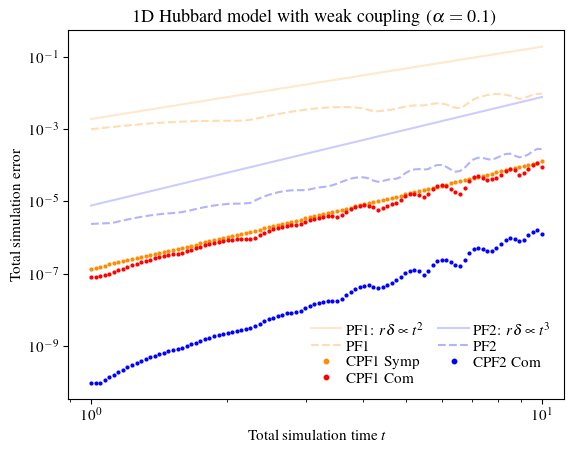

In [11]:
nsteps=100
x = ticks

fig, ax = plt.subplots()

nticks = len(ticks)
y_PF1_step_error = [data_CPF1_errors[i][0] for i in range(nticks)]
y_PF1_rsteps_error = list(nsteps * np.array(y_PF1_step_error))
y_PF1_error      = [data_CPF1_errors[i][3] for i in range(nticks)]
y_CPF1symp_error = [data_CPF1_errors[i][4] for i in range(nticks)]
y_CPF1com_error  = [data_CPF1_errors[i][5] for i in range(nticks)]

y_PF2_step_error = [data_CPF2_errors[i][0] for i in range(nticks)]
y_PF2_rsteps_error = list(nsteps * np.array(y_PF2_step_error))
y_PF2_error      = [data_CPF2_errors[i][3] for i in range(nticks)]
y_CPF2com_error  = [data_CPF2_errors[i][5] for i in range(nticks)]

plt.loglog(x, y_PF1_rsteps_error, ls="-", color='darkorange',  label='PF1: $r\delta\propto t^2$', markersize=4, alpha=0.2)
plt.loglog(x, y_PF1_error, ls='dashed', color='darkorange',  label='PF1', markersize=4, alpha=.3)
plt.loglog(x, y_CPF1symp_error, '.', color='darkorange',   label='CPF1 Symp', markersize=4)
plt.loglog(x, y_CPF1com_error, '.', color='red',   label='CPF1 Com', markersize=4)
plt.loglog(x, y_PF2_rsteps_error, ls="-", color='blue',  label='PF2: $r\delta\propto t^3$', markersize=4, alpha=0.2)
plt.loglog(x, y_PF2_error, ls='dashed', color='blue',  label='PF2', markersize=4, alpha=.3)
plt.loglog(x, y_CPF2com_error, '.', color='blue',   label='CPF2 Com', markersize=4)

plt.xlabel('Total simulation time $t$')
plt.ylabel('Total simulation error')
plt.title('1D Hubbard model with weak coupling ($\\alpha=0.1$)')

ax.legend(markerscale=1.6, ncol=2, frameon=False,
    handletextpad=0.3,
    columnspacing=1,
    labelspacing=0.15
)
plt.show()

In [16]:
# Simulations with a fixed time step
tau = 0.1
steps_list = np.arange(1, 101, dtype=int)
size_steps_list = len(steps_list)

data_CPF1_errors = data_CPF_error_fixed_step(1, H_hub_wc, A_hub_wc, B_hub_wc, tau, steps_list)
data_CPF2_errors = data_CPF_error_fixed_step(2, H_hub_wc, A_hub_wc, B_hub_wc, tau, steps_list)

100%|██████████| 100/100 [00:36<00:00,  2.73it/s]


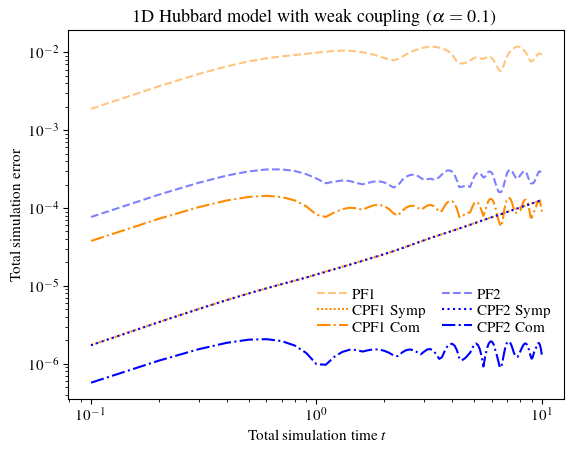

In [20]:
x = steps_list * tau

fig, ax = plt.subplots()

y_PF1_error      = [data_CPF1_errors[i][3] for i in range(size_steps_list)]
y_CPF1symp_error = [data_CPF1_errors[i][4] for i in range(size_steps_list)]
y_CPF1com_error  = [data_CPF1_errors[i][5] for i in range(size_steps_list)]

y_PF2_error      = [data_CPF2_errors[i][3] for i in range(size_steps_list)]
y_CPF2symp_error = [data_CPF2_errors[i][4] for i in range(size_steps_list)]
y_CPF2com_error  = [data_CPF2_errors[i][5] for i in range(size_steps_list)]

plt.loglog(x, y_PF1_error, ls="dashed", color= 'darkorange',  label='PF1', alpha=.5)
plt.loglog(x, y_CPF1symp_error, ls=(0,(1,1)), color='darkorange',  label='CPF1 Symp')
plt.loglog(x, y_CPF1com_error, ls='dashdot', color='darkorange',  label='CPF1 Com')

plt.loglog(x, y_PF2_error, ls='dashed', color='blue',  label='PF2', alpha=.5)
plt.loglog(x, y_CPF2symp_error, ls='dotted', color='blue',   label='CPF2 Symp')
plt.loglog(x, y_CPF2com_error, ls="dashdot", color='blue',   label='CPF2 Com')

ax.legend(markerscale=1.6, ncol=2, frameon=False,
    handletextpad=0.3,
    columnspacing=1,
    labelspacing=0.15, loc='lower right', bbox_to_anchor=(1, 0.14)
)

plt.xlabel('Total simulation time $t$')
plt.ylabel('Total simulation error')
plt.title('1D Hubbard model with weak coupling ($\\alpha=0.1$)')
plt.show()